# Kamdojizdime.cz — explorácia dát pre napojenie do pipeline

**Cieľ:** nie "pozrieť si dáta", ale vytiahnuť z nich **konkrétne čísla, ktoré nahradia
odhadnuté parametre v pipeline**. Notebook je preto stavaný okolo tejto tabuľky:

| Čo z dát | Nahradí / spresní | Kde v kóde |
|---|---|---|
| `dojizdka`/`vyjizdka`, typ 1 | `external_commuting_scale` (dnes 0.65 – fudge faktor) | `src/sim/defaults.py` → `demand.sldb.external_processing` |
| `dojizdka`/`vyjizdka`, typ 2/3/6 | `segments.external_local.total_daily_trips` (dnes 130 000 pre Brno) | `config/brno/sim.yaml` |
| `denni_chod` | `demand_period_split_from_day` (am/ip/pm) | `defaults.py` → `demand.temporal_policy` |
| `denni_chod` | `time_slices.segments.external_local` (am/ip/pm/ev) | `defaults.py` → `demand.time_slices` |
| `denni_chod` (dni v týždni) | day-type faktory z `learn-profile` | `src/sim/demand/temporal.py` |
| `tranzitujici` | `through_traffic_scale` (dnes 0.30 pre Brno) | `config/brno/sim.yaml` — **pozor, viď §8** |

**Zdroj pravdy pre výklad stĺpcov** je metodika ŘSD/INTENS
`data/kam_dojizdime_zima_22_23/27_metodicky-postup-reseni-zima-2022-2023.pdf`;
odkazy na kapitoly (§7.1–7.3, §3.5) sú uvedené pri jednotlivých sekciách.

---

### Spustenie

Notebook **nepotrebuje aequilibrae ani geopandas** — beží aj na Pythone 3.14,
kde sa zvyšok pipeline nenainštaluje:

```bash
python3 -m venv .venv-nb && source .venv-nb/bin/activate
pip install pandas matplotlib jupyter pyyaml
jupyter lab notebooks/kamdojizdime_explorace.ipynb
```

Spúšťaj z koreňa repa (cesty sú relatívne k nemu).

## 0. Setup

In [1]:
from pathlib import Path
import sys, re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# --- cesty: notebook beží z koreňa repa alebo z notebooks/ ---
ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent
DATA = ROOT / "data"
sys.path.insert(0, str(ROOT / "src"))

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.1f}")

# --- paleta (validovaná na CVD odstupy; 6 slotov = 6 typov cesty) ---
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]
INK, INK2, GRID = "#0b0b0b", "#52514e", "#dcdcd8"

plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "600", "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": INK2, "ytick.color": INK2, "font.size": 9,
    "legend.frameon": False,
})

def thousands(ax, axis="y"):
    f = mtick.FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", " "))
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(f)

print("ROOT:", ROOT)

ROOT: /Users/magdalena.ondruskova/git/personal/Traffic-sim-backend


## 1. Slovník metodiky

Toto je najdôležitejšia bunka v notebooku — bez správneho výkladu `typ_cesty` sa
celý zvyšok počíta zle. Hodnoty sú z metodiky **§7.2, Tabuľka č. 2, stĺpec E**
(nie z odhadu):

> *„Typ cesty 1 = T1; 2 = T2; 3 = T3; 4 = D2; 5 = PN; 6 = N."*

Dve veci, ktoré sa ľahko prehliadnu:

- **`pocet_osob` nie je počet ciest.** Je to *počet rezidentov zdrojovej obce,
  ktorí majú voči cieľovej obci pridelený daný príznak* — za celé 28-dňové obdobie
  merania. Prevod na cesty/deň je **náš predpoklad**, nie údaj z dát (viď §6).
- **`pocet_osob_pd` = „pracovná doba", nie „pracovný deň".** Metodika §7.2, stĺpec G:
  všedné dni **6:00–18:00**. Pre D2 (4) a PN (5) sa z podstaty veci neurčuje → v dátach 0.

In [2]:
TYP_CESTY = {
    1: ("T1", "dojížďka za prací/školou",       "pravidelná; ≥13 pobytov a ≥50 h za 28 dní"),
    2: ("T2", "intenzivní dojížďka za službami","≥4 pobyty a ≥8 h; mimo T1"),
    3: ("T3", "občasná dojížďka za službami",   "≥2 pobyty a ≥4 h; mimo T1/T2"),
    4: ("D2", "druhé bydlení",                  "≥6 prenocovaní; NEsčítava sa (už je v T2/T3)"),
    5: ("PN", "přenocující návštěvník",         "≥1 prenocovanie; bez príznaku T1–T3"),
    6: ("N",  "návštěvník",                     "jeden pobyt ≥3 h; bez predošlých príznakov"),
}
TYP_LABEL = {k: f"{k} {v[0]} – {v[1]}" for k, v in TYP_CESTY.items()}
TYP_COLOR = {k: PALETTE[k - 1] for k in TYP_CESTY}

# typy, ktoré vôbec dávajú zmysel ako zdroj dennej dopravy do modelu
TYPY_DENNE   = [1]           # pravidelná dojížďka
TYPY_OBCASNE = [2, 3, 6]     # služby + návštevníci → external_local segment
TYPY_MIMO    = [4, 5]        # druhé bydlení, prenocujúci — nie denná doprava

display(pd.DataFrame(
    [(k, *v) for k, v in TYP_CESTY.items()],
    columns=["typ_cesty", "kód", "význam", "kritérium (metodika §5)"],
).set_index("typ_cesty"))

,kód,význam,kritérium (metodika §5)
typ_cesty,,,
1,T1,dojížďka za prací/školou,pravidelná; ≥13 pobytov a ≥50 h za 28 dní
2,T2,intenzivní dojížďka za službami,≥4 pobyty a ≥8 h; mimo T1
3,T3,občasná dojížďka za službami,≥2 pobyty a ≥4 h; mimo T1/T2
4,D2,druhé bydlení,≥6 prenocovaní; NEsčítava sa (už je v T2/T3)
5,PN,přenocující návštěvník,≥1 prenocovanie; bez príznaku T1–T3
6,N,návštěvník,jeden pobyt ≥3 h; bez predošlých príznakov


## 2. Načítanie — a čo znamená prázdna bunka

Loader musí riešiť tri veci naraz:

1. `sep=";"`, `encoding="utf-8-sig"` (súbor `bydlici` má BOM),
2. **prázdna bunka ≠ nula.** Podľa metodiky §3.5 je kritická hodnota pre zverejnenie **7**:
   `≥7` = zverejnené, `1–6.9` = **potlačené**, `0` = vzťah neexistuje.
   V exporte je potlačená hodnota **prázdna**, nie `"xx"`. Miešať tieto dva stavy
   znamená podhodnotiť dlhý chvost relácií — preto ich držíme oddelene v stĺpci `cenzurovane`.
3. sezóny sú 4 samostatné adresáre; radíme ich chronologicky, nie abecedne.

In [3]:
SEZONY = [  # (adresár, krátky názov) v chronologickom poradí
    ("kam_dojizdime_podzim_21",   "podzim 21"),
    ("kam_dojizdime_jaro_22",     "jaro 22"),
    ("kam_dojizdime_leto_22",     "léto 22"),
    ("kam_dojizdime_zima_22_23",  "zima 22/23"),
]
SEZONY = [(d, n) for d, n in SEZONY if (DATA / d).is_dir()]
BRNO = "582786"

def _read(sezona_dir, kind):
    p = DATA / sezona_dir / f"{BRNO}_{kind}.csv"
    return pd.read_csv(p, sep=";", encoding="utf-8-sig", dtype=str) if p.exists() else None

def load_od(kind):
    """kind: 'dojizdka' (X → Brno) alebo 'vyjizdka' (Brno → X)."""
    out = []
    for d, name in SEZONY:
        df = _read(d, kind)
        if df is None:
            continue
        df["sezona"] = name
        df["smer"] = kind
        for c in ("pocet_osob", "pocet_osob_pd"):
            df[c] = pd.to_numeric(df[c], errors="coerce")
        df["typ_cesty"] = df["typ_cesty"].astype(int)
        # prázdne = potlačené anonymizáciou; 0 = vzťah neexistuje
        df["cenzurovane"] = df["pocet_osob"].isna()
        df["partner"] = df["obec_zdroj"] if kind == "dojizdka" else df["obec_cil"]
        df["partner_kod"] = df["kod_zdroj"] if kind == "dojizdka" else df["kod_cil"]
        out.append(df)
    return pd.concat(out, ignore_index=True)

DNI = ["pondělí", "úterý", "středa", "čtvrtek", "pátek", "sobota", "neděle"]

def load_denni_chod():
    out = []
    for d, name in SEZONY:
        df = _read(d, "denni_chod")
        if df is None:
            continue
        df["sezona"] = name
        for c in df.columns:
            if c not in ("obec", "kod", "obdobi", "casovy_interval_den",
                         "casovy_interval_cas", "sezona"):
                df[c] = pd.to_numeric(df[c], errors="coerce")
        df["den"] = pd.Categorical(df["casovy_interval_den"], categories=DNI, ordered=True)
        # "00:00 - 01:00" → 0  (pandas úvodzovky z CSV už odstránil)
        df["hodina"] = df["casovy_interval_cas"].str.extract(r"^(\d{1,2}):")[0].astype(int)
        df["vikend"] = df["den"].isin(["sobota", "neděle"])
        out.append(df)
    return pd.concat(out, ignore_index=True)

def load_bydlici():
    out = []
    for d, name in SEZONY:
        df = _read(d, "bydlici")
        if df is None:
            continue
        df["sezona"] = name
        for c in df.columns:
            if c not in ("obec", "kod", "obdobi", "sezona"):
                df[c] = pd.to_numeric(df[c], errors="coerce")
        out.append(df)
    return pd.concat(out, ignore_index=True)

doj = load_od("dojizdka")     # X → Brno
vyj = load_od("vyjizdka")     # Brno → X
od  = pd.concat([doj, vyj], ignore_index=True)
dch = load_denni_chod()
byd = load_bydlici()

print(f"sezóny: {[n for _, n in SEZONY]}")
print(f"OD riadkov: {len(od):,}  |  denní chod: {len(dch):,}  |  bydlící: {len(byd):,}")

sezóny: ['podzim 21', 'jaro 22', 'léto 22', 'zima 22/23']
OD riadkov: 194,139  |  denní chod: 672  |  bydlící: 4


In [4]:
# Inventár: čo v ktorej sezóne je
inv = (od.groupby(["sezona", "smer"], observed=True)
         .agg(riadkov=("pocet_osob", "size"),
              obci=("partner_kod", "nunique"),
              cenzurovanych=("cenzurovane", "sum"))
         .reset_index())
inv["cenzurovanych_%"] = 100 * inv["cenzurovanych"] / inv["riadkov"]
display(inv)

,sezona,smer,riadkov,obci,cenzurovanych,cenzurovanych_%
0,jaro 22,dojizdka,23862,5964,15636,65.5
1,jaro 22,vyjizdka,25039,5927,14958,59.7
2,léto 22,dojizdka,23684,5921,15435,65.2
3,léto 22,vyjizdka,26196,6049,14866,56.7
4,podzim 21,dojizdka,22305,5838,14667,65.8
5,podzim 21,vyjizdka,25841,5977,15576,60.3
6,zima 22/23,dojizdka,23197,5780,15063,64.9
7,zima 22/23,vyjizdka,24015,5737,15277,63.6


## 3. Cenzúra: koľko OD matice v skutočnosti chýba

Toto je **najtvrdšie obmedzenie zdroja** a treba ho poznať skôr, než sa čokoľvek
napojí do modelu. Ak je potlačených ~65 % relácií, OD matica z tohto zdroja
**nie je kompletná** — je useknutá zľava.

Dobrá správa: každá potlačená hodnota je z definície `< 7 osôb`, takže chýbajúcu
masu vieme **ohraničiť**, nie len odhadnúť. Dolná hranica = `n × 1`, horná = `n × 6.9`.

In [5]:
def cenzura_prehlad(df, sezona=None):
    d = df if sezona is None else df[df["sezona"] == sezona]
    g = d.groupby(["smer", "typ_cesty"], observed=True).agg(
        relacii=("pocet_osob", "size"),
        cenzurovanych=("cenzurovane", "sum"),
        nulovych=("pocet_osob", lambda s: int((s == 0).sum())),
        zverejnenych_osob=("pocet_osob", "sum"),
    ).reset_index()
    g["cenzura_%"] = 100 * g["cenzurovanych"] / g["relacii"]
    g["skryte_min"] = g["cenzurovanych"] * 1.0     # dolná hranica
    g["skryte_max"] = g["cenzurovanych"] * 6.9     # horná hranica
    g["skryte_max_%"] = 100 * g["skryte_max"] / (g["zverejnenych_osob"] + g["skryte_max"])
    g["typ"] = g["typ_cesty"].map(lambda k: TYP_CESTY[k][0])
    return g

SEZONA_REF = "zima 22/23" if "zima 22/23" in set(od["sezona"]) else SEZONY[-1][1]
cen = cenzura_prehlad(od, SEZONA_REF)
display(cen[["smer", "typ_cesty", "typ", "relacii", "cenzurovanych", "cenzura_%",
             "zverejnenych_osob", "skryte_max", "skryte_max_%"]])

,smer,typ_cesty,typ,relacii,cenzurovanych,cenzura_%,zverejnenych_osob,skryte_max,skryte_max_%
0,dojizdka,1,T1,2559,1764,68.9,"97,289.8","12,171.6",11.1
1,dojizdka,2,T2,3962,2485,62.7,"127,268.1","17,146.5",11.9
2,dojizdka,3,T3,4640,2699,58.2,"138,038.6","18,623.1",11.9
3,dojizdka,4,D2,2353,2014,85.6,"8,595.9","13,896.6",61.8
4,dojizdka,5,PN,4345,3448,79.4,"40,730.4","23,791.2",36.9
5,dojizdka,6,N,5338,2653,49.7,"142,650.7","18,305.7",11.4
6,vyjizdka,1,T1,2556,2073,81.1,"26,514.3","14,303.7",35.0
7,vyjizdka,2,T2,4169,2693,64.6,"69,734.3","18,581.7",21.0
8,vyjizdka,3,T3,4693,2692,57.4,"119,022.0","18,574.8",13.5
9,vyjizdka,4,D2,2546,2111,82.9,"10,374.2","14,565.9",58.4


findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


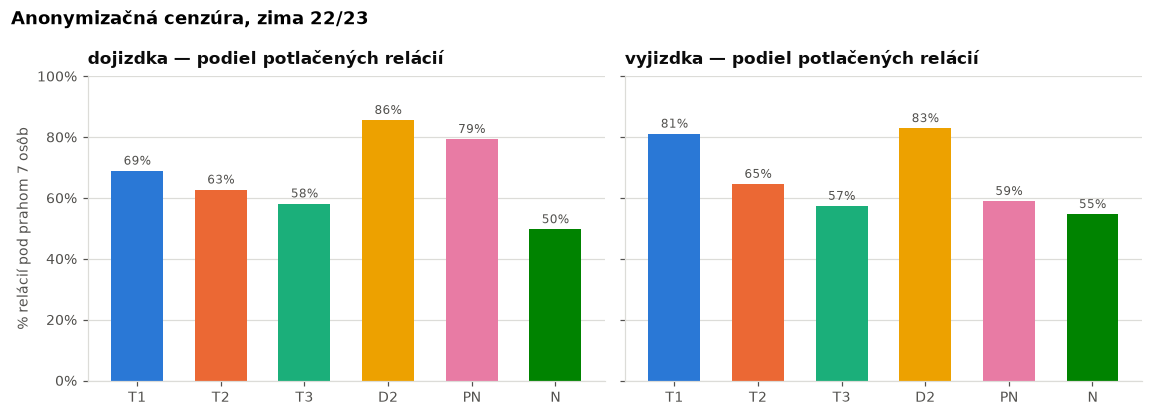

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), sharey=True)
for ax, smer in zip(axes, ["dojizdka", "vyjizdka"]):
    d = cen[cen["smer"] == smer].sort_values("typ_cesty")
    bars = ax.bar([TYP_CESTY[t][0] for t in d["typ_cesty"]], d["cenzura_%"],
                  color=[TYP_COLOR[t] for t in d["typ_cesty"]], width=0.62)
    ax.bar_label(bars, fmt="%.0f%%", padding=2, color=INK2, fontsize=8)
    ax.set_title(f"{smer} — podiel potlačených relácií", pad=8)
    ax.set_ylim(0, 100); ax.grid(axis="x", visible=False)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_ylabel("% relácií pod prahom 7 osôb")
fig.suptitle(f"Anonymizačná cenzúra, {SEZONA_REF}", x=0.008, ha="left", fontsize=12, weight="600")
fig.tight_layout(); plt.show()

**Ako to čítať pre model:** vysoké % cenzúry pri type 1 znamená veľa *malých* obcí
s väzbou na Brno, ktoré v matici nie sú. Stĺpec `skryte_max_%` hovorí, koľko
percent objemu môže maximálne chýbať — ak je to jednotky percent, zdroj je pre
gateway/externé toky použiteľný a chýbajúci chvost sa dá dorovnať existujúcim
SLDB rozdelením. Ak sú to desiatky percent, tento zdroj **nesmie** SLDB nahradiť,
len ho kalibrovať.

## 4. Objemy podľa typu cesty a smeru

`dojizdka` a `vyjizdka` **nie sú transpozíciou tej istej matice.** `dojizdka` =
rezidenti *iných obcí* s príznakom voči Brnu; `vyjizdka` = rezidenti *Brna*
s príznakom voči iným obciam. Sú to dve rôzne populácie, takže asymetria je
očakávaná — nie chyba dát. Pre model to znamená, že smerové toky treba brať
oddelene, nie symetrizovať.

smer,dojizdka,vyjizdka,pomer doj/vyj
1 T1 – dojížďka za prací/školou,"97,289.8","26,514.3",3.7
2 T2 – intenzivní dojížďka za službami,"127,268.1","69,734.3",1.8
3 T3 – občasná dojížďka za službami,"138,038.6","119,022.0",1.2
4 D2 – druhé bydlení,"8,595.9","10,374.2",0.8
5 PN – přenocující návštěvník,"40,730.4","99,179.9",0.4
6 N – návštěvník,"142,650.7","137,077.8",1.0


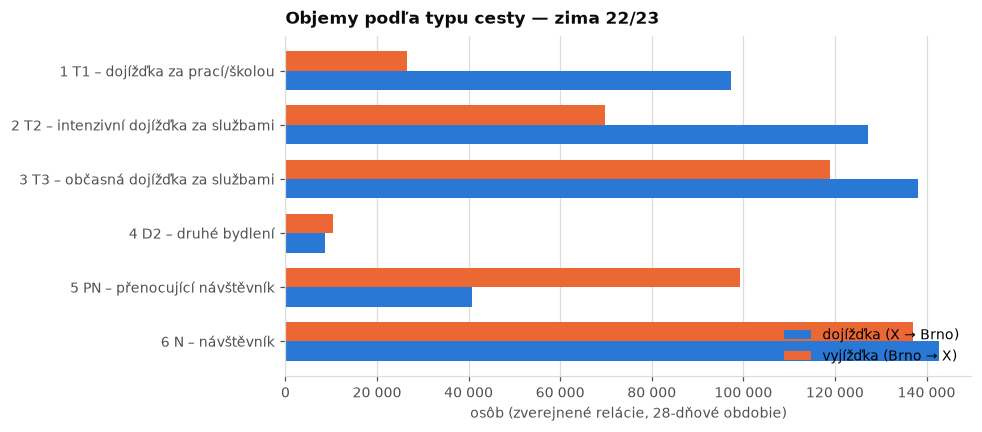

In [7]:
vol = (od[od["sezona"] == SEZONA_REF]
       .groupby(["smer", "typ_cesty"], observed=True)["pocet_osob"].sum()
       .unstack("smer").fillna(0))
vol.index = [TYP_LABEL[t] for t in vol.index]
vol["pomer doj/vyj"] = vol["dojizdka"] / vol["vyjizdka"]
display(vol)

fig, ax = plt.subplots(figsize=(9, 4))
y = range(len(vol))
h = 0.36
ax.barh([i + h/2 for i in y], vol["dojizdka"], height=h, color=PALETTE[0], label="dojížďka (X → Brno)")
ax.barh([i - h/2 for i in y], vol["vyjizdka"], height=h, color=PALETTE[1], label="vyjížďka (Brno → X)")
ax.set_yticks(list(y)); ax.set_yticklabels(vol.index); ax.invert_yaxis()
ax.set_xlabel("osôb (zverejnené relácie, 28-dňové obdobie)")
ax.set_title(f"Objemy podľa typu cesty — {SEZONA_REF}", pad=8)
ax.grid(axis="y", visible=False); thousands(ax, "x"); ax.legend(loc="lower right")
fig.tight_layout(); plt.show()

In [8]:
# Podiel "v pracovnej dobe" (Po–Pá 6–18) — proxy pre to, koľko z väzby je reálne
# dopravou v špičkových hodinách. Pre D2 (4) a PN (5) sa neurčuje → očakávame 0.
pd_share = (od[od["sezona"] == SEZONA_REF]
            .groupby(["smer", "typ_cesty"], observed=True)[["pocet_osob", "pocet_osob_pd"]].sum())
pd_share["podiel_PD_%"] = 100 * pd_share["pocet_osob_pd"] / pd_share["pocet_osob"]
pd_share.index = pd.MultiIndex.from_tuples(
    [(s, TYP_LABEL[t]) for s, t in pd_share.index], names=["smer", "typ"])
display(pd_share)

pocet_osob  pocet_osob_pd  podiel_PD_%
smer     typ                                                                           
dojizdka 1 T1 – dojížďka za prací/školou           97,289.8       74,271.9         76.3
         2 T2 – intenzivní dojížďka za službami   127,268.1      110,406.2         86.8
         3 T3 – občasná dojížďka za službami      138,038.6      104,110.9         75.4
         4 D2 – druhé bydlení                       8,595.9            0.0          0.0
         5 PN – přenocující návštěvník             40,730.4            0.0          0.0
         6 N – návštěvník                         142,650.7      113,050.2         79.2
vyjizdka 1 T1 – dojížďka za prací/školou           26,514.3       13,376.7         50.5
         2 T2 – intenzivní dojížďka za službami    69,734.3       48,954.7         70.2
         3 T3 – občasná dojížďka za službami      119,022.0       70,245.6         59.0
         4 D2 – druhé bydlení                      10,374.2            0.0          0.0
         5 PN – přenocující návštěvník             99,179.9            0.0          0.0
         6 N – návštěvník                         137,077.8      114,926.4         83.8

## 5. Koncentrácia — koľko obcí model naozaj potrebuje

Pipeline mapuje externé toky na **gateways** (D1, D2, I/43, I/52 podľa
`config/brno/sim.yaml`), nie na 5 700 obcí. Otázka teda znie: koľko partnerských
obcí nesie väčšinu objemu? Ak 95 % objemu pokrýva pár stoviek obcí, agregácia na
gateway je bezstratová a zvyšok je šum pod prahom cenzúry.

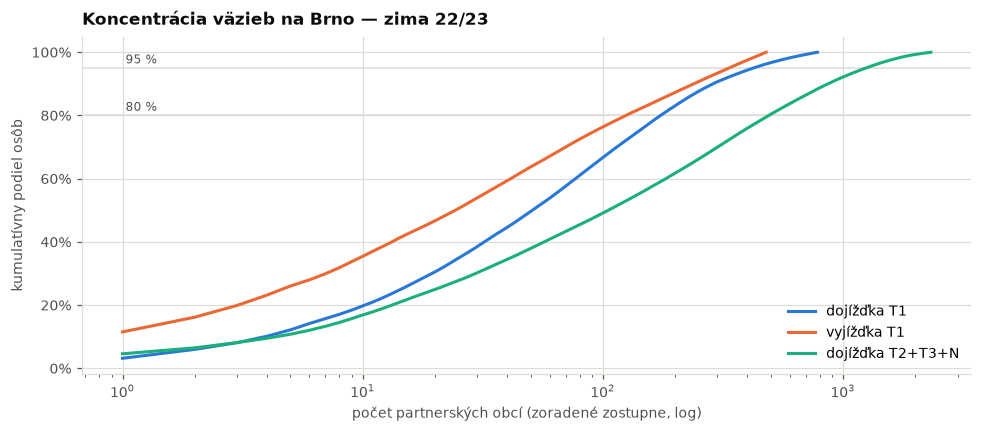

,obcí s objemom,obcí pre 50%,obcí pre 80%,obcí pre 90%,obcí pre 95%
vzťah,,,,,
dojížďka T1,783,51,174,288,424
vyjížďka T1,479,25,125,240,335
dojížďka T2+T3+N,2323,106,491,866,1245


In [9]:
def krivka_pokrytia(smer, typy, sezona=SEZONA_REF):
    d = od[(od["smer"] == smer) & (od["sezona"] == sezona) & (od["typ_cesty"].isin(typy))]
    s = d.groupby("partner")["pocet_osob"].sum().sort_values(ascending=False)
    s = s[s > 0]
    return s, (s.cumsum() / s.sum())

fig, ax = plt.subplots(figsize=(9, 4))
rows = []
for i, (smer, typy, lbl) in enumerate([
        ("dojizdka", TYPY_DENNE,   "dojížďka T1"),
        ("vyjizdka", TYPY_DENNE,   "vyjížďka T1"),
        ("dojizdka", TYPY_OBCASNE, "dojížďka T2+T3+N")]):
    s, cum = krivka_pokrytia(smer, typy)
    ax.plot(range(1, len(cum) + 1), 100 * cum.values, lw=2, color=PALETTE[i], label=lbl)
    rows.append({"vzťah": lbl, "obcí s objemom": len(s),
                 **{f"obcí pre {p}%": int((cum < p / 100).sum()) + 1 for p in (50, 80, 90, 95)}})

for p in (80, 95):
    ax.axhline(p, color=GRID, lw=1, zorder=0)
    ax.annotate(f"{p} %", (1, p), xytext=(2, 3), textcoords="offset points",
                color=INK2, fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("počet partnerských obcí (zoradené zostupne, log)")
ax.set_ylabel("kumulatívny podiel osôb")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title(f"Koncentrácia väzieb na Brno — {SEZONA_REF}", pad=8)
ax.legend(loc="lower right")
fig.tight_layout(); plt.show()

display(pd.DataFrame(rows).set_index("vzťah"))

In [10]:
# TOP 15 partnerských obcí pre pravidelnú dojížďku — sanity check voči očakávaniu
top = (od[(od["smer"] == "dojizdka") & (od["sezona"] == SEZONA_REF)
          & (od["typ_cesty"].isin(TYPY_DENNE))]
       .groupby("partner")["pocet_osob"].sum().sort_values(ascending=False).head(15))
display(top.to_frame("osôb T1 → Brno"))

,osôb T1 → Brno
partner,
Kuřim,"3,104.1"
Šlapanice,"2,742.7"
Blansko,"2,060.4"
Modřice,"1,991.7"
Moravany,"1,951.6"
Bílovice nad Svitavou,"1,947.2"
Rosice,"1,532.8"
Rajhrad,"1,303.3"
Tišnov,"1,292.1"


## 6. Osoby → vozidlá: kde presne vstupuje predpoklad

Toto je miesto, kde sa dá najľahšie pomýliť. Dáta dávajú **osoby s príznakom za 28 dní**.
Model potrebuje **vozidlá za deň**. Medzi tým sú tri násobiče, z ktorých
pipeline už dva má (`demand.conversion`) a tretí — **frekvencia ciest** — v dátach nie je
a musí sa predpokladať.

Pre **T1** je predpoklad obhájiteľný: kritérium príznaku je ≥13 pobytov a ≥50 h
za 28 dní, čo je de facto definícia pravidelného dochádzajúceho → `frekvencia ≈ 1 deň/deň`.
Pre **T2/T3/N** to obhájiteľné **nie je** — príznak dostane aj ten, kto prišiel 2× za mesiac.
Preto je frekvencia nižšie explicitný parameter a nižšie je aj citlivosť na jeho voľbu.

In [11]:
from sim.defaults import SIM_DEFAULTS
import yaml

CONV = SIM_DEFAULTS["demand"]["conversion"]
EXT  = SIM_DEFAULTS["demand"]["sldb"]["external_processing"]
brno_cfg = yaml.safe_load((ROOT / "config/brno/sim.yaml").read_text(encoding="utf-8"))

print("pipeline conversion.work :", CONV["work"])
print("external_commuting_scale:", EXT["external_commuting_scale"], " (fudge faktor, ktorý chceme nahradiť)")
print("through_traffic_scale   :", brno_cfg["demand"]["sldb"]["external_processing"]["through_traffic_scale"], "(brno override)")
print("external_local          :", brno_cfg["demand"]["segments"]["external_local"])

pipeline conversion.work : {'car_share': 0.48, 'occupancy': 1.2, 'trips_per_person': 2.0}
external_commuting_scale: 0.65  (fudge faktor, ktorý chceme nahradiť)
through_traffic_scale   : 0.3 (brno override)
external_local          : {'total_daily_trips': 130000}


In [12]:
W = CONV["work"]

def osoby_na_vozidla(osob, frekvencia=1.0, conv=W):
    """osoby s príznakom → vozidlo-ciest/deň (obojsmerne)."""
    return osob * frekvencia * conv["car_share"] / conv["occupancy"] * conv["trips_per_person"]

t1_doj = vol.loc[TYP_LABEL[1], "dojizdka"]
t1_vyj = vol.loc[TYP_LABEL[1], "vyjizdka"]

print(f"T1 dojížďka do Brna : {t1_doj:>10,.0f} osôb  →  {osoby_na_vozidla(t1_doj):>9,.0f} voz-ciest/deň")
print(f"T1 vyjížďka z Brna  : {t1_vyj:>10,.0f} osôb  →  {osoby_na_vozidla(t1_vyj):>9,.0f} voz-ciest/deň")
print(f"\nspolu externá pravidelná doprava: {osoby_na_vozidla(t1_doj + t1_vyj):,.0f} voz-ciest/deň")
print(f"(pri car_share={W['car_share']}, occupancy={W['occupancy']}, trips_per_person={W['trips_per_person']})")

T1 dojížďka do Brna :     97,290 osôb  →     77,832 voz-ciest/deň
T1 vyjížďka z Brna  :     26,514 osôb  →     21,211 voz-ciest/deň

spolu externá pravidelná doprava: 99,043 voz-ciest/deň
(pri car_share=0.48, occupancy=1.2, trips_per_person=2.0)


,frekvencia,voz-ciest/deň,"vs. external_local (130,000)"
dní/28 dní,,,
1,0.0,"20,965.5",0.2
2,0.1,"41,930.9",0.3
4,0.1,"83,861.9",0.6
8,0.3,"167,723.8",1.3
14,0.5,"293,516.6",2.3
28,1.0,"587,033.2",4.5


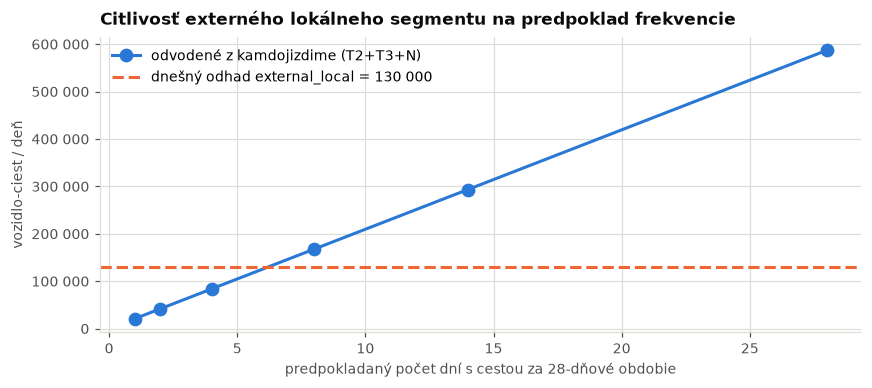

Dnešný odhad external_local = 130,000 voz-ciest/deň implicitne predpokladá,
že osoba s príznakom T2/T3/N cestuje do Brna ~6.2 dní z 28
(≈ 1.6× týždenne).


In [13]:
# Citlivosť na frekvenciu pre občasné typy (T2+T3+N) → porovnanie s external_local segmentom
obcasne = vol.loc[[TYP_LABEL[t] for t in TYPY_OBCASNE], ["dojizdka", "vyjizdka"]].sum().sum()
cielova = brno_cfg["demand"]["segments"]["external_local"]["total_daily_trips"]

sens = pd.DataFrame({
    "dní/28 dní": [1, 2, 4, 8, 14, 28],
})
sens["frekvencia"] = sens["dní/28 dní"] / 28
sens["voz-ciest/deň"] = sens["frekvencia"].map(lambda f: osoby_na_vozidla(obcasne, f))
sens[f"vs. external_local ({cielova:,})"] = sens["voz-ciest/deň"] / cielova
display(sens.set_index("dní/28 dní"))

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(sens["dní/28 dní"], sens["voz-ciest/deň"], lw=2, marker="o",
        ms=8, color=PALETTE[0], label="odvodené z kamdojizdime (T2+T3+N)")
ax.axhline(cielova, lw=2, ls="--", color=PALETTE[1],
           label=f"dnešný odhad external_local = {cielova:,}".replace(",", " "))
ax.set_xlabel("predpokladaný počet dní s cestou za 28-dňové obdobie")
ax.set_ylabel("vozidlo-ciest / deň")
ax.set_title("Citlivosť externého lokálneho segmentu na predpoklad frekvencie", pad=8)
thousands(ax); ax.legend()
fig.tight_layout(); plt.show()

# Spätný dopočet: aký predpoklad frekvencie je implicitne v dnešnom ručnom odhade?
implied_dni = 28 * cielova / osoby_na_vozidla(obcasne, 1.0)
print(f"Dnešný odhad external_local = {cielova:,} voz-ciest/deň implicitne predpokladá,")
print(f"že osoba s príznakom T2/T3/N cestuje do Brna ~{implied_dni:.1f} dní z 28")
print(f"(≈ {7 * implied_dni / 28:.1f}× týždenne).")

**Priesečník krivky s prerušovanou čiarou je použiteľný výsledok:** hovorí, aký
predpoklad frekvencie je *implicitne zabudovaný* v dnešnom ručnom odhade
`total_daily_trips`. Ak vyjde nepravdepodobná hodnota (napr. „každý návštevník
chodí 20 z 28 dní"), je to argument, že dnešný odhad je nadsadený — a naopak.

## 7. Denní chod → časové parametre

168 záznamov na sezónu (24 h × 7 dní), priemerované cez 28 dní merania (metodika §7.3).

**Zásadná výhrada, ktorú treba uviesť aj v článku:** `denni_chod` je **prítomnosť
osôb v obci**, nie intenzita dopravy. Kto je práve *na ceste* (bez pobytu ≥30 min
v hodinovom intervale), padá do internej kategórie „na cestě", ktorá **v exporte
nie je** — teda ani v `pritomni_celkem`. Špička v prítomnosti je preto *posunutá
a vyhladená* oproti špičke v doprave: prítomnosť rastie, až keď ľudia dorazia.
Používať sa dá na **tvar dňa a typ dňa**, nie ako priama náhrada CSD profilov.

In [14]:
KOMP = ["rezidenti", "dojizdejici_prace", "dojizdejici_intenzivne", "dojizdejici_obcasne",
        "nocujici", "navstevnici", "tranzitujici"]

d = dch[dch["sezona"] == SEZONA_REF]
kontrola = pd.DataFrame({
    "pritomni_celkem": d["pritomni_celkem"],
    "suma_zloziek": d[KOMP].sum(axis=1),
})
kontrola["rozdiel_%"] = 100 * (kontrola["suma_zloziek"] / kontrola["pritomni_celkem"] - 1)
print("Kontrola metodiky §7.3: pritomni_celkem ≈ súčet stĺpcov F–L (bez druhe_bydleni)")
print(kontrola["rozdiel_%"].describe()[["mean", "min", "max"]])
print("\n→ ak sú odchýlky v desatinách %, ide o zaokrúhlenie + zarušenie, čo metodika pripúšťa.")

Kontrola metodiky §7.3: pritomni_celkem ≈ súčet stĺpcov F–L (bez druhe_bydleni)
mean   -0.0
min    -0.0
max     0.0
Name: rozdiel_%, dtype: float64

→ ak sú odchýlky v desatinách %, ide o zaokrúhlenie + zarušenie, čo metodika pripúšťa.


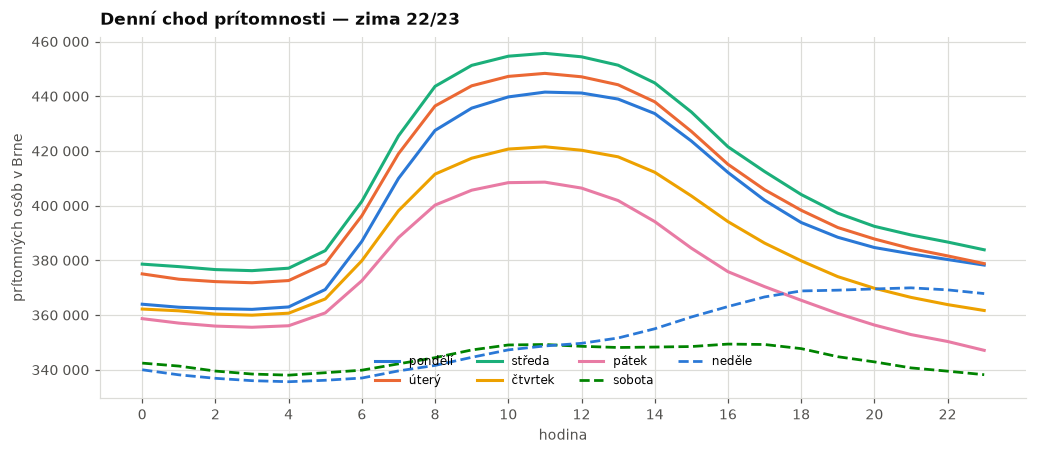

den,pondělí,úterý,středa,čtvrtek,pátek,sobota,neděle
hodina,,,,,,,
3,"362,097.0","371,829.0","376,250.0","359,977.0","355,556.0","338,450.0","336,023.0"
7,"409,964.0","418,992.0","425,508.0","398,155.0","388,337.0","342,175.0","339,596.0"
9,"435,671.0","443,834.0","451,305.0","417,363.0","405,668.0","347,250.0","344,556.0"
12,"441,195.0","447,130.0","454,436.0","420,278.0","406,439.0","348,588.0","349,680.0"
15,"423,654.0","427,174.0","434,270.0","403,580.0","384,480.0","348,507.0","359,306.0"
17,"401,996.0","405,852.0","412,504.0","386,331.0","370,411.0","349,255.0","366,642.0"
20,"384,707.0","387,829.0","392,458.0","369,813.0","356,375.0","342,898.0","369,566.0"


In [15]:
# Denný profil prítomnosti podľa dňa v týždni
piv = (d.pivot_table(index="hodina", columns="den", values="pritomni_celkem", observed=True)
         .reindex(columns=DNI))
fig, ax = plt.subplots(figsize=(9.5, 4.2))
for i, den in enumerate(DNI):
    vikend = den in ("sobota", "neděle")
    ax.plot(piv.index, piv[den], lw=2 if not vikend else 1.8,
            color=PALETTE[i % len(PALETTE)], ls="-" if not vikend else "--", label=den)
ax.set_xlabel("hodina"); ax.set_ylabel("prítomných osôb v Brne")
ax.set_xticks(range(0, 24, 2)); thousands(ax)
ax.set_title(f"Denní chod prítomnosti — {SEZONA_REF}", pad=8)
ax.legend(ncol=4, loc="lower center", fontsize=8)
fig.tight_layout(); plt.show()
display(piv.loc[[3, 7, 9, 12, 15, 17, 20]].round(0))

In [16]:
# Day-type faktory: víkend vs. všedný deň (nezávislá kontrola pre learn-profile)
denne = d.groupby("den", observed=True)["pritomni_celkem"].mean()
vsedne = denne.loc[DNI[:5]].mean()
dayfac = (denne / vsedne).to_frame("faktor vs. priemer Po–Pá")
display(dayfac)

,faktor vs. priemer Po–Pá
den,
pondělí,1.0
úterý,1.0
středa,1.0
čtvrtek,1.0
pátek,0.9
sobota,0.9
neděle,0.9


demand_period_split_from_day : {'am': 0.35, 'ip': 0.4, 'pm': 0.25}
fallback_day_period_shares   : {'day': 0.785, 'evening': 0.137, 'night': 0.078}
time_slices.external_local   : {'am': 0.28, 'ip': 0.22, 'pm': 0.3, 'ev': 0.2}


,hodiny,príchody,odchody,pohyb spolu,podiel_3obd,default_3obd,podiel_4obd,default_external_local
am,6–10,"59,090.6",0.0,"59,090.6",0.5,0.3,0.5,0.3
ip,10–15,"4,381.6","10,552.2","14,933.8",0.1,0.4,0.1,0.2
pm,15–19,0.0,"36,287.4","36,287.4",0.3,0.2,0.3,0.3
ev,19–23,0.0,"15,734.4","15,734.4",NaN,NaN,0.1,0.2


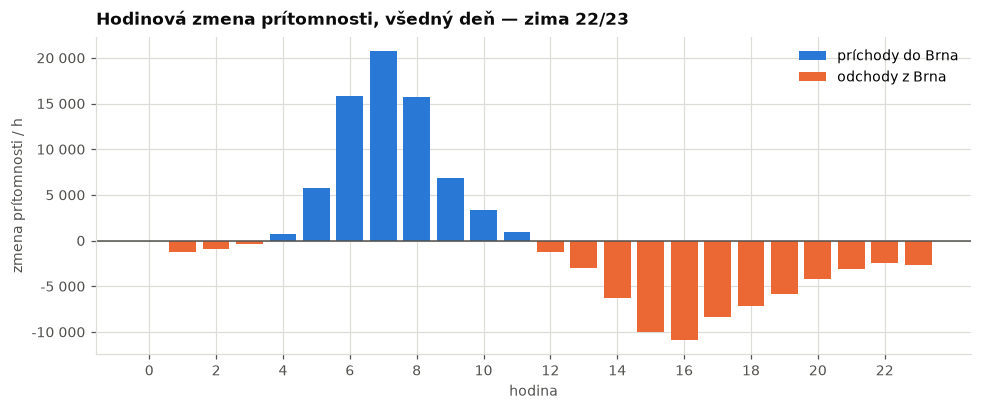

In [17]:
# --- am / ip / pm split ---
# Pipeline delí DENNÝ objem na špičky podľa demand_period_split_from_day (3 obdobia)
# a navyše má 4-obdobový split priamo pre segment external_local — ten je pre nás
# najrelevantnejší, lebo práve ten segment ideme z týchto dát prepočítať.
TEMP   = SIM_DEFAULTS["demand"]["temporal_policy"]
SLICES = SIM_DEFAULTS["demand"]["time_slices"]["segments"]
print("demand_period_split_from_day :", TEMP["demand_period_split_from_day"])
print("fallback_day_period_shares   :", TEMP["fallback_day_period_shares"])
print("time_slices.external_local   :", SLICES["external_local"])

# proxy pre dopravu: hodinová zmena prítomnosti (netto príchody / odchody)
vs = d[~d["vikend"]].groupby("hodina", observed=True)["pritomni_celkem"].mean()
delta = vs.diff().fillna(0)
prichody, odchody = delta.clip(lower=0), (-delta).clip(lower=0)

OKNA = {"am": range(6, 10), "ip": range(10, 15), "pm": range(15, 19), "ev": range(19, 23)}
pohyb = pd.DataFrame({
    "hodiny":   {k: f"{min(h)}–{max(h) + 1}" for k, h in OKNA.items()},
    "príchody": {k: prichody.loc[list(h)].sum() for k, h in OKNA.items()},
    "odchody":  {k: odchody.loc[list(h)].sum()  for k, h in OKNA.items()},
})
pohyb["pohyb spolu"] = pohyb[["príchody", "odchody"]].sum(axis=1)
# 3-obdobový podiel (bez ev) → porovnateľné s demand_period_split_from_day
bez_ev = pohyb.loc[["am", "ip", "pm"], "pohyb spolu"]
pohyb["podiel_3obd"] = (bez_ev / bez_ev.sum()).reindex(pohyb.index)
pohyb["default_3obd"] = pd.Series(TEMP["demand_period_split_from_day"])
# 4-obdobový podiel → porovnateľné s time_slices.segments.external_local
pohyb["podiel_4obd"] = pohyb["pohyb spolu"] / pohyb["pohyb spolu"].sum()
pohyb["default_external_local"] = pd.Series(SLICES["external_local"])
display(pohyb)

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(vs.index, prichody, color=PALETTE[0], width=0.8, label="príchody do Brna")
ax.bar(vs.index, -odchody, color=PALETTE[1], width=0.8, label="odchody z Brna")
ax.axhline(0, color=INK2, lw=1)
ax.set_xticks(range(0, 24, 2)); ax.set_xlabel("hodina")
ax.set_ylabel("zmena prítomnosti / h"); thousands(ax)
ax.set_title(f"Hodinová zmena prítomnosti, všedný deň — {SEZONA_REF}", pad=8)
ax.legend(); fig.tight_layout(); plt.show()

Pozor pri interpretácii: prírastok prítomnosti je **netto** (príchody mínus odchody
v tej istej hodine), takže systematicky **podhodnocuje** obojsmernú dopravu —
najviac v obedňajšom sedle, kde sa toky rušia. Ako odhad *tvaru* AM/PM špičky to
stačí, ako odhad *objemu* nie.

In [18]:
# --- den / večer / noc, vrátane citlivosti na voľbu hraníc ---
# CSD (a teda learn-profile) používa vlastné hranice; tu ukazujeme, ako veľmi
# na nich výsledok závisí, aby sa dali zladiť s definíciou v CSD dátach.
def podiely(den_od, den_do, vec_do):
    hod = vs.copy()
    den = hod.loc[[h for h in hod.index if den_od <= h < den_do]].sum()
    vec = hod.loc[[h for h in hod.index if den_do <= h < vec_do]].sum()
    noc = hod.sum() - den - vec
    t = den + vec + noc
    return {"den": den / t, "vecer": vec / t, "noc": noc / t}

var = pd.DataFrame({f"{a}–{b}, večer do {c}": podiely(a, b, c)
                    for a, b, c in [(6, 18, 22), (6, 18, 21), (7, 19, 22), (6, 19, 22)]}).T
var.loc["dnešný fallback v pipeline"] = [
    TEMP["fallback_day_period_shares"]["day"],
    TEMP["fallback_day_period_shares"]["evening"],
    TEMP["fallback_day_period_shares"]["night"]]
display(var.style.format("{:.3f}"))

,den,vecer,noc
"6–18, večer do 22",0.529,0.161,0.310
"6–18, večer do 21",0.529,0.121,0.350
"7–19, večer do 22",0.529,0.120,0.351
"6–19, večer do 22",0.570,0.120,0.310
dnešný fallback v pipeline,0.785,0.137,0.078


## 8. `tranzitujici` — prečo to **nie je** tranzitná doprava

V pláne je uvedené porovnanie `tranzitujici` vs. supernetwork through-traffic.
Metodika §7.3, stĺpec L to však definuje inak:

> *„počet osob, které měly v daném intervalu dominantní pobyt v dané obci a které
> nemají vůči dané obci žádný příznak… SIM karta má v obci pobyt alespoň 30 minut,
> avšak nemá vůči obci žádný příznak přidělen."*

Čiže je to **neklasifikovaný pobyt ≥30 min**, nie prejazd. Kto Brnom naozaj
*prejde* bez zastávky, v tomto stĺpci nie je vôbec — spadol do internej kategórie
„na cestě", ktorá sa neexportuje. Stĺpec je teda skôr zvyšková kategória
(„ostatné") než tranzit.

**Dôsledok:** `tranzitujici` sa **nedá** použiť na kalibráciu `through_traffic_scale`.
Ako validačná vrstva pre tranzit ostáva supernetwork + CSD. Nižšie je aspoň
rádová veľkosť, aby bolo vidieť, o akú zložku ide.

In [19]:
tr = (dch.groupby("sezona", observed=True)
        .apply(lambda g: pd.Series({
            "tranzitujici priemer/h": g["tranzitujici"].mean(),
            "tranzitujici max/h": g["tranzitujici"].max(),
            "podiel na prítomných %": 100 * g["tranzitujici"].sum() / g["pritomni_celkem"].sum(),
        }), include_groups=False))
display(tr)

,tranzitujici priemer/h,tranzitujici max/h,podiel na prítomných %
sezona,,,
jaro 22,"1,734.9","4,433.2",0.5
léto 22,"2,108.0","5,561.4",0.6
podzim 21,"1,534.0","3,971.9",0.4
zima 22/23,"1,429.6","3,648.8",0.4


## 9. Sezónnosť — ktorú sezónu použiť ako baseline

Model je kalibrovaný na CSD 2025 (celoročné priemery / pracovný deň). Otázka je,
ktorá sezóna je k tomu najbližšie a aká veľká je sezónna variácia — to je zároveň
samostatný výsledok pre článok (sezónna validácia).

kat,D2/PN,T1 pravidelná,T2/T3/N občasná
sezona,,,
podzim 21,"201,275.5","137,124.4","826,106.7"
jaro 22,"198,304.4","123,115.5","867,943.3"
léto 22,"200,052.7","98,174.1","895,062.7"
zima 22/23,"158,880.4","123,804.1","733,791.5"


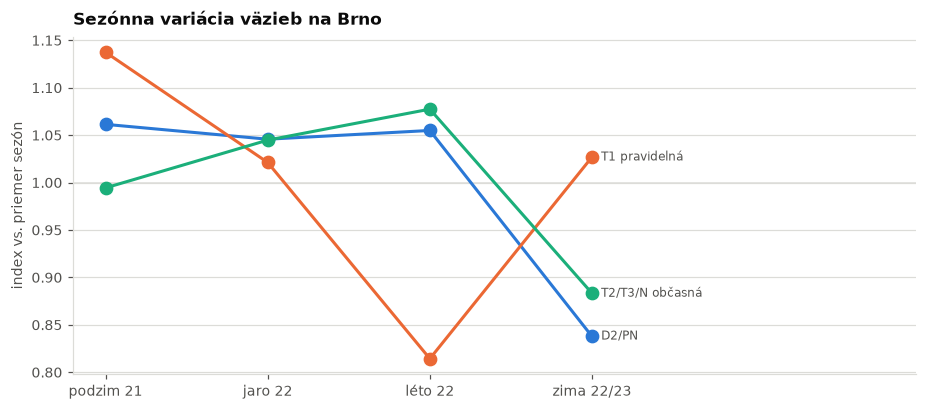

In [20]:
sez = (od.groupby(["sezona", "smer", "typ_cesty"], observed=True)["pocet_osob"].sum()
         .reset_index())
sez["kat"] = sez["typ_cesty"].map(lambda t: "T1 pravidelná" if t in TYPY_DENNE
                                  else ("T2/T3/N občasná" if t in TYPY_OBCASNE else "D2/PN"))
piv_s = (sez.groupby(["sezona", "kat"], observed=True)["pocet_osob"].sum()
            .unstack("kat").reindex([n for _, n in SEZONY]))
display(piv_s)

rel = piv_s / piv_s.mean()
fig, ax = plt.subplots(figsize=(8.5, 3.8))
for i, c in enumerate(rel.columns):
    ax.plot(rel.index, rel[c], lw=2, marker="o", ms=8, color=PALETTE[i], label=c)
    ax.annotate(c, (len(rel) - 1, rel[c].iloc[-1]), xytext=(6, 0),
                textcoords="offset points", color=INK2, fontsize=8, va="center")
ax.axhline(1.0, color=GRID, lw=1, zorder=0)
ax.set_ylabel("index vs. priemer sezón"); ax.set_xlim(-0.2, len(rel) - 0.2 + 1.2)
ax.set_title("Sezónna variácia väzieb na Brno", pad=8)
ax.grid(axis="x", visible=False)
fig.tight_layout(); plt.show()

## 10. `bydlici` — kontrolné súčty

Jeden riadok na sezónu, agregát za Brno (metodika §7.1, Tabuľka č. 1). Slúži na
dve veci: kontrolný súčet voči OD matici a porovnanie počtu rezidentov voči
ČSÚ/SLDB, ktoré pipeline používa na populáciu zón.

**Čo kontrolný súčet dokazuje a čo nie.** Metodika §3.5 definuje stĺpec
„Vyjíždějící za prací/školou" (Tab. 1) *ako súčet nezanonymizovaných T1 relácií
z Tab. 2*, s poznámkou, že drobné rozdiely spôsobuje anonymizácia a zaokrúhľovanie.
Zhoda teda potvrdzuje:

- výklad `typ_cesty = 1` → T1 (keby to bol iný typ, súčet by nesedel rádovo),
- smer (`vyjizdka` = rezidenti Brna von, nie naopak),
- parsovanie čísel (oddeľovač `;`, desatinná bodka).

**Nepotvrdzuje** správne zaobchádzanie s cenzúrou — prázdna bunka aj nula
prispejú do súčtu rovnako (ničím), takže tento test medzi nimi nerozlíši.
Rozlíšenie prázdna ≠ nula je dôležité až pri počítaní *relácií* a chýbajúcej masy (§3).

Presný rozdiel je v jednotkách osôb z desiatok tisíc, nie nula — čo je presne to,
čo metodika predpovedá. Exaktná nula by bola skôr podozrivá (naznačovala by, že
Tab. 1 vznikla tou istou agregáciou až po anonymizácii).

In [21]:
display(byd.set_index("sezona")[["rezidenti", "nevyjizdejici", "vyjizdejici_prace",
                                 "vyjizdejici_intenzivne", "vyjizdejici_obcasne",
                                 "bez_sim", "druhe_bydleni", "nocujici", "navstevnici"]])

# Kontrolný súčet: T1 vyjížďka z Tabuľky 2 vs. "vyjizdejici_prace" z Tabuľky 1.
# Metodika §3.5 hovorí, že stĺpec G Tabuľky 1 JE súčtom nezanonymizovaných T1 relácií
# z Tabuľky 2, a že drobné rozdiely spôsobuje "anonymizace a zaokrouhlování".
kontrola = []
for _, name in SEZONY:
    m = (od["smer"] == "vyjizdka") & (od["sezona"] == name) & (od["typ_cesty"] == 1)
    t1 = od.loc[m, "pocet_osob"].sum()
    tab1 = byd.loc[byd["sezona"] == name, "vyjizdejici_prace"].iloc[0]
    kontrola.append({
        "sezona": name,
        "Σ T1 vyjížďka (Tab. 2)": t1,
        "vyjizdejici_prace (Tab. 1)": tab1,
        "rozdiel (osôb)": t1 - tab1,
        "rozdiel (%)": 100 * (t1 / tab1 - 1),
        "cenzurovaných relácií": int(od.loc[m, "cenzurovane"].sum()),
    })
k = pd.DataFrame(kontrola).set_index("sezona")
display(k.style.format({"Σ T1 vyjížďka (Tab. 2)": "{:,.1f}", "vyjizdejici_prace (Tab. 1)": "{:,.1f}",
                        "rozdiel (osôb)": "{:+.1f}", "rozdiel (%)": "{:+.4f} %"}))

,rezidenti,nevyjizdejici,vyjizdejici_prace,vyjizdejici_intenzivne,vyjizdejici_obcasne,bez_sim,druhe_bydleni,nocujici,navstevnici
sezona,,,,,,,,,
podzim 21,439213,205520,"34,538.3","70,122.9","66,677.6","57,178.0","10,396.8","52,876.3",143489
jaro 22,433745,205800,"28,328.9","70,189.2","68,473.7","56,465.4","11,361.5","55,247.5",147224
léto 22,403143,173988,"25,393.9","82,354.6","64,562.3","52,481.6","10,732.4","49,157.8",135072
zima 22/23,431043,226864,"26,512.8","54,230.4","62,769.8","56,113.6","12,977.7","49,693.8",150282


,Σ T1 vyjížďka (Tab. 2),vyjizdejici_prace (Tab. 1),rozdiel (osôb),rozdiel (%),cenzurovaných relácií
sezona,,,,,
podzim 21,"34,541.3","34,538.3",+3.0,+0.0087 %,2221
jaro 22,"28,327.1","28,328.9",-1.8,-0.0064 %,1952
léto 22,"25,397.1","25,393.9",+3.2,+0.0126 %,1832
zima 22/23,"26,514.3","26,512.8",+1.5,+0.0057 %,2073


## 11. `SRCH-37188_zoznam_rus.csv` — neidentifikovaný súbor

Leží iba v adresári `zima_22_23`, má jeden stĺpec `rus` a **žiadny prienik
s kódmi obcí** v OD matici. Rozsah hodnôt tomu tiež nezodpovedá. Nie je súčasťou
troch tabuliek popísaných v metodike — pred akýmkoľvek použitím treba zistiť
pôvod (pravdepodobne výstup samostatného dotazu, nie časť dodávky).

In [22]:
p = DATA / "kam_dojizdime_zima_22_23" / "SRCH-37188_zoznam_rus.csv"
if p.exists():
    rus = pd.read_csv(p, sep=";", encoding="utf-8-sig")
    kody = set(od["partner_kod"].dropna().astype(str))
    print(f"riadkov: {len(rus)}, stĺpce: {list(rus.columns)}")
    print(f"rozsah: {rus['rus'].min():,} – {rus['rus'].max():,}")
    print(f"prienik s kódmi obcí v OD matici: {len(set(rus['rus'].astype(str)) & kody)}")
    display(rus.head())
else:
    print("súbor nie je k dispozícii")

súbor nie je k dispozícii


## 12. Zhrnutie — čo z toho ide do pipeline

Posledná bunka zloží dokopy čísla odvodené vyššie. To je vstup pre rozhodnutie
**replace vs. blend** (otvorená otázka č. 1 v `KAMDOJIZDIME_PLAN.md`).

In [23]:
souhrn = pd.DataFrame([
    {"parameter": "externá pravidelná doprava (T1, oba smery)",
     "hodnota": f"{osoby_na_vozidla(t1_doj + t1_vyj):,.0f} voz-ciest/deň",
     "nahrádza": "external_commuting_scale = %s (fudge)" % EXT["external_commuting_scale"],
     "spoľahlivosť": "vysoká — T1 kritérium ≈ pravidelný dochádzajúci"},
    {"parameter": "externý lokálny segment (T2+T3+N)",
     "hodnota": f"{obcasne:,.0f} osôb → závisí od frekvencie (viď §6)",
     "nahrádza": f"external_local.total_daily_trips = {cielova:,}",
     "spoľahlivosť": "nízka — frekvencia ciest nie je v dátach"},
    {"parameter": "am/ip/pm split",
     "hodnota": ", ".join(f"{k}={v:.2f}" for k, v in pohyb["podiel_3obd"].dropna().items()),
     "nahrádza": str(TEMP["demand_period_split_from_day"]),
     "spoľahlivosť": "stredná — prítomnosť, nie tok; netto podhodnocuje"},
    {"parameter": "time_slices external_local (am/ip/pm/ev)",
     "hodnota": ", ".join(f"{k}={v:.2f}" for k, v in pohyb["podiel_4obd"].items()),
     "nahrádza": str(SLICES["external_local"]),
     "spoľahlivosť": "stredná — rovnaká výhrada ako vyššie"},
    {"parameter": "day-type faktory",
     "hodnota": ", ".join(f"{d}={v:.2f}" for d, v in
                          dayfac["faktor vs. priemer Po–Pá"].items() if d in ("sobota", "neděle")),
     "nahrádza": "learn-profile z CSD (nezávislá kontrola)",
     "spoľahlivosť": "stredná — porovnať s CSD, nie nahradiť"},
    {"parameter": "through_traffic_scale",
     "hodnota": "NEPOUŽITEĽNÉ",
     "nahrádza": "— (viď §8: 'tranzitujici' je neklasifikovaný pobyt, nie prejazd)",
     "spoľahlivosť": "—"},
    {"parameter": "úplnosť OD matice",
     "hodnota": f"{100 * cen.loc[cen['smer'] == 'dojizdka', 'cenzurovanych'].sum() / cen.loc[cen['smer'] == 'dojizdka', 'relacii'].sum():.0f} % relácií potlačených",
     "nahrádza": "— obmedzenie zdroja",
     "spoľahlivosť": "chýbajúca masa ohraničená < 7 osôb/relácia"},
])
display(souhrn.set_index("parameter"))

,hodnota,nahrádza,spoľahlivosť
parameter,,,
"externá pravidelná doprava (T1, oba smery)","99,043 voz-ciest/deň",external_commuting_scale = 0.65 (fudge),vysoká — T1 kritérium ≈ pravidelný dochádzajúci
externý lokálny segment (T2+T3+N),"733,792 osôb → závisí od frekvencie (viď §6)","external_local.total_daily_trips = 130,000",nízka — frekvencia ciest nie je v dátach
am/ip/pm split,"am=0.54, ip=0.14, pm=0.33","{'am': 0.35, 'ip': 0.4, 'pm': 0.25}","stredná — prítomnosť, nie tok; netto podhodnocuje"
time_slices external_local (am/ip/pm/ev),"am=0.47, ip=0.12, pm=0.29, ev=0.12","{'am': 0.28, 'ip': 0.22, 'pm': 0.3, 'ev': 0.2}",stredná — rovnaká výhrada ako vyššie
day-type faktory,"sobota=0.87, neděle=0.89",learn-profile z CSD (nezávislá kontrola),"stredná — porovnať s CSD, nie nahradiť"
through_traffic_scale,NEPOUŽITEĽNÉ,— (viď §8: 'tranzitujici' je neklasifikovaný p...,—
úplnosť OD matice,65 % relácií potlačených,— obmedzenie zdroja,chýbajúca masa ohraničená < 7 osôb/relácia


### Ďalší krok

Až keď tieto čísla sedia, má zmysel písať loader do `src/sim/datasets/`. Poradie
podľa predošlej diskusie: loader + unit testy (bez aequilibrae) → napojenie na
`build-demand` → `distribute`/`assign` v kontajneri → kalibrácia.

Otvorené otázky z `KAMDOJIZDIME_PLAN.md`, ktoré tento notebook **zatvára**:

- ~~č. 2: poradie `typ_cesty` 1–6~~ → overené v metodike §7.2 (Tabuľka č. 2, stĺpec E), viď §1.
- č. 1 (replace vs. blend) → podklad je §3 (cenzúra) + §12; rozhodnutie je stále na tebe.
- č. 4 (len Brno) → platí, dáta sú iba pre obec 582786, ale **všetky 4 sezóny**, nie len zima.